In [3]:
import rasterio
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dist_s1.dist_plot import get_dist_s1_mpl_cmap

In [38]:
MGRS_TILE_ID = '22MGB' #'33MXS' #'50NPL' # '21MWP' # '19LCF' # '20LMM' '20MMA'
MGRS_TILE_ID = '21MWP'
MGRS_TILE_ID = '19LCF'
MGRS_TILE_ID = '50NPL'

In [39]:
dist_hls_dir = list(Path('dist_hls/').glob(f'*_{MGRS_TILE_ID}/'))[0]
dist_hls_dir

PosixPath('dist_hls/treelosswet__50NPL')

In [40]:
dist_ts_dir = Path('opera_dist_data/')
ts_dir = list(dist_ts_dir.glob(f'*_{MGRS_TILE_ID}/'))[0]
ts_dir

PosixPath('opera_dist_data/treelosswet__50NPL')

In [41]:
status_files = sorted(list(ts_dir.rglob('OPERA*_GEN-DIST-STATUS.tif')))
status_files[:3]

[PosixPath('opera_dist_data/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240105T215803Z_20260205T195711Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240105T215803Z_20260205T195711Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('opera_dist_data/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240112T214955Z_20260205T195137Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240112T214955Z_20260205T195137Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('opera_dist_data/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240117T215802Z_20260205T191908Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240117T215802Z_20260205T191908Z_S1A_30_v0.1_GEN-DIST-STATUS.tif')]

In [42]:
def get_acq_time(path):
    opera_id = path.stem
    tokens = opera_id.split('_')
    acq_time = pd.to_datetime(tokens[4])
    return acq_time

ts_start = get_acq_time(status_files[0])
ts_end = get_acq_time(status_files[-1])
ts_start, ts_end


(Timestamp('2024-01-05 21:58:03+0000', tz='UTC'),
 Timestamp('2024-12-30 21:57:58+0000', tz='UTC'))

In [43]:
def open_one_arr(path):
    with rasterio.open(path) as src:
        return src.read(1)

In [44]:
status_files_hls_gen = sorted(list(dist_hls_dir.rglob('OPERA*_GEN-DIST-STATUS.tif')))
n = len(status_files_hls_gen)
status_files_hls_gen = status_files_hls_gen[-n//4:]
status_arrs_hls_gen = list(map(open_one_arr, status_files_hls_gen))

In [45]:
status_files_hls_veg = sorted(list(dist_hls_dir.rglob('OPERA*_VEG-DIST-STATUS.tif')))
n = len(status_files_hls_veg)
status_files_hls_veg = status_files_hls_veg[-n//4:]
status_arrs_hls_veg = list(map(open_one_arr, status_files_hls_veg))

In [46]:
status_arrs_stacked_hls_veg = np.stack(status_arrs_hls_veg, axis=0)
status_arrs_stacked_hls_gen = np.stack(status_arrs_hls_gen, axis=0)

In [47]:
with rasterio.open(status_files[0]) as src:
    p_dist = src.profile
    cmap_dist = src.colormap(1)


In [48]:
confirmed_low_mask_hls_gen = (status_arrs_stacked_hls_gen == 3).any(axis=0)
confirmed_high_mask_hls_gen = (status_arrs_stacked_hls_gen == 6).any(axis=0)

In [49]:
confirmed_low_mask_hls_veg = (status_arrs_stacked_hls_veg == 3).any(axis=0)
confirmed_high_mask_hls_veg = (status_arrs_stacked_hls_veg == 6).any(axis=0)

In [50]:
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()

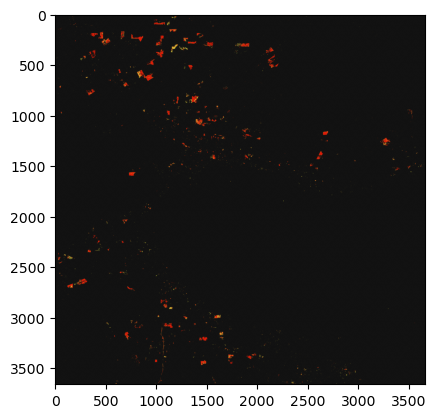

In [51]:
status_agg_veg = np.zeros(status_arrs_stacked_hls_veg.shape[1:], dtype=np.uint8)
status_agg_veg[confirmed_low_mask_hls_veg] = 3
status_agg_veg[confirmed_high_mask_hls_veg] = 6
plt.imshow(status_agg_veg, cmap=dist_cmap, norm=dist_norm)

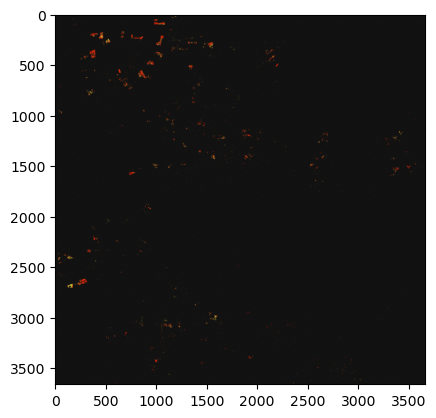

In [52]:
status_agg_gen = np.zeros(status_arrs_stacked_hls_gen.shape[1:], dtype=np.uint8)
status_agg_gen[confirmed_low_mask_hls_gen] = 3
status_agg_gen[confirmed_high_mask_hls_gen] = 6
plt.imshow(status_agg_gen, cmap=dist_cmap, norm=dist_norm)

In [53]:
COMP_DIR = Path(f'comparison_dir / {MGRS_TILE_ID}')
COMP_DIR.mkdir(exist_ok=True, parents=True)

In [54]:
p = p_dist.copy()
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_dist_hls_agg_gen_{ts_end.year}_alerts.tif', 'w', **p) as ds:
    ds.write(status_agg_gen, 1)
    ds.write_colormap(1, cmap_dist)

p = p_dist.copy()
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_dist_hls_agg_veg_{ts_end.year}_alerts.tif', 'w', **p) as ds:
    ds.write(status_agg_veg, 1)
    ds.write_colormap(1, cmap_dist)